In [ ]:
import pandas as pd

In [ ]:
diabetes = pd.read_csv('diabetes.csv')

In [ ]:
diabetes

Diabetic jest zmienną objaśnianą y, zaś pozostałe zmiennymi objaśniającymi X (nie bierzemy pod uwagę PatientID, ponieważ jest to indeks pacjenta i nie jest informatywny dla modelu).

In [ ]:
features = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']  # lista kolumn (cech) używanych do analizy i budowy modelu

target = 'Diabetic'  # nazwa kolumny zawierającej zmienną docelową (czy pacjent ma cukrzycę)

X, y = diabetes[features], diabetes[target]  # podział danych na cechy wejściowe (X) oraz zmienną docelową (y)

print('X:')  # wyświetlenie nagłówka dla cech wejściowych

display(X)  # wyświetlenie tabeli zawierającej wybrane cechy wszystkich pacjentów

print('\ny:')  # wyświetlenie nagłówka dla zmiennej docelowej (\n dodaje pustą linię)

display(y)  # wyświetlenie kolumny informującej, czy pacjent choruje na cukrzycę

# TLUMACZENIE CHATA

Co robi ten kod?

Zakładamy, że diabetes jest obiektem DataFrame z biblioteki Pandas zawierającym dane pacjentów.

1. Wybór cech (features)
features = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure',
            'TricepsThickness','SerumInsulin','BMI',
            'DiabetesPedigree','Age']

Tworzona jest lista kolumn, które będą używane jako dane wejściowe do modelu.

Znaczenie kolumn:

Kolumna	Opis
Pregnancies	liczba ciąż
PlasmaGlucose	poziom glukozy we krwi
DiastolicBloodPressure	ciśnienie rozkurczowe
TricepsThickness	grubość fałdu skórnego na tricepsie
SerumInsulin	poziom insuliny
BMI	wskaźnik masy ciała
DiabetesPedigree	wskaźnik obciążenia genetycznego cukrzycą
Age	wiek pacjenta
2. Wybór zmiennej docelowej
target = 'Diabetic'

Kolumna Diabetic zawiera informację, czy pacjent ma cukrzycę.

Najczęściej:

0 = brak cukrzycy
1 = cukrzyca
3. Podział danych
X, y = diabetes[features], diabetes[target]

Tworzone są dwa zbiory:

X – dane wejściowe (8 kolumn z cechami pacjenta)

Przykład:

Pregnancies	PlasmaGlucose	BMI	Age
2	95	24.5	30
4	140	31.2	45

y – odpowiedź, którą model ma przewidywać

Diabetic
0
1
4. Wyświetlenie danych
display(X)
display(y)

Pokazuje zawartość obu zmiennych.

Opis wyniku

Otrzymałeś:

y:
0        0
1        0
2        0
3        1
4        0
        ..
14995    1
14996    1
14997    0
14998    0
14999    1
Name: Diabetic, Length: 15000, dtype: int64

To jest seria (Series) Pandas zawierająca wartości kolumny Diabetic.

Jak to czytać?
0        0
pierwszy 0 = indeks wiersza
drugi 0 = wartość w kolumnie Diabetic

Czyli:

Pacjent o indeksie 0 nie ma cukrzycy.

3        1

oznacza:

Pacjent o indeksie 3 ma cukrzycę.

Co oznacza ..?
4        0
        ..
14995    1

Pandas nie pokazuje wszystkich 15000 rekordów, tylko początek i koniec zbioru.

Co oznacza:
Name: Diabetic

Nazwa kolumny, z której pochodzą dane.

Co oznacza:
Length: 15000

W zbiorze znajduje się 15000 pacjentów (rekordów).

Co oznacza:
dtype: int64

Typ danych to liczby całkowite 64-bitowe (integer).

Ponieważ kolumna zawiera tylko wartości 0 i 1, jest to typowe kodowanie dla problemu klasyfikacji binarnej:

0 → osoba zdrowa
1 → osoba chora na cukrzycę

Taki zbiór danych jest przygotowany do uczenia modelu klasyfikacyjnego (np. Logistic Regression, Decision Tree, Random Forest), który na podstawie cech z X będzie przewidywał wartość y (czy pacjent ma cukrzycę).

# cd szkolenia nizej

Zrozumienie, czyli abyśmy wiedzieli, jak dane wpływają na zmienną zależną, czy zmienna nie jest na przykład wyciekiem danych. Tutaj się zatrzymajmy na chwilę. Możesz się zastanawiać jaka zmienna może być wyciekiem. Naprawdę jest to proste! Nie możesz stosować cech, które nie są znane przed wykonywaniem prognozy.

Przykład – załóżmy, że klasyfikujesz czy samolot będzie opóźniony. Nie możesz wykorzystać realnej godziny przylotu, ponieważ ta informacji jest znana dopiero po wylądowaniu i model wykorzystujący taką zmienną byłby nieużyteczny. Ponadto wykorzystując dane, które są wyciekiem danych uzyskujemy zbyt optymistyczne wyniki.

Wróćmy do eksploracji danych, jej celem jest również decyzja o przetwarzaniu danych, czyli usunięcie wartości odstających, tworzenie nowych cech w oparciu o już istniejące (Feature engineering) czy usunięcie zmiennych ze sobą skorelowanych (tak jak w regresji zrobiliśmy dla temperatury oraz temperatury odczuwalnej) lub zmiennych, które nie mają wpływ na zmienną objaśnianą. Pamiętaj, to jest pewien przewodnik, jednak nie jest to zawsze działający przepis! Możesz nauczyć się robić przepyszne ciasto u siebie w domu, ale jeśli ciocia poprosi Cię o zrobienie ciasta w jej kuchni, gdzie foremka i piekarnik są inne, to też należy lekko zmienić przepis, aby ponownie ciasto było przepyszne.

Analizę danych dla problemu klasyfikacji najlepiej zacząć od zmiennej objaśnianej ~ y. Jak już wcześniej się dowiedzieliśmy, ważne aby sprawdzić czy klasy są zbalansowane, czyli czy jest ich po równo. Umieśćmy y w Data Series, a następnie zastosujmy metodę value_counts, dzięki której sprawdzimy unikalne klasy i liczbę ich wystąpień. Parametr normalize domyślnie jest ustawiony na False, zmieniając na True zobaczymy procentowy udział klas – szczególnie przy wielu różnych unikalnych wartościach wynik jest bardziej klarowny.

In [ ]:
pd.Series(y).value_counts(normalize=True)

1/3 badanych osób była cukrzykami. Należy mieć tę informację w pamięci, ponieważ tworząc model, który zawsze klasyfikuje osoby jako nie cukrzyków będzie miał dokładność 66.6667%. Oczywiście taki model nie będzie dobrym, ale o tym już nie raz mogliśmy się przekonać.

Sprawdźmy typy danych oraz sprawdźmy czy są wartości brakujące. Wykorzystamy metodę info na całej ramce danych.

In [ ]:
diabetes.info()

# wazne info o brakach danych

Brak wartości brakujących, a typy danych, które się pojawiły to wartości numeryczne. Jeśli pojawiłyby się braki w danych (często tak się dzieje) to należałoby je uzupełnić. Jednak nie możemy uzupełniać braków na całym zbiorze, ponieważ to ponownie wyciek danych! Braki danych uzupełniamy na podstawie wiedzy ze zbioru treningowego, ponieważ zakładamy, że dane ze zbioru testowego są dla nas nieznane. W związku z tym jeśli mamy braki dla wartości numerycznej, to uzupełnić możemy je średnią bądź medianą ze zbioru treningowego, a braki dla wartości kategorycznej uzupełniamy modą, czyli najczęściej występującą kategorią ze zbioru treningowego.

Sprawdźmy rozkłady, wykorzystując metodę describe. W tym przypadku możemy to wykonać jedynie dla X, ponieważ już wiemy, że y to zmienna objaśniana kategoryczna (znamy też jej rozkład).

In [ ]:
X.describe()

# WAZNE 

Teraz będziemy porównywać zmienne numeryczne X do zmiennej kategorycznej y. W tym przypadku dobrym pomysłem jest wykorzystanie wykresów pudełkowych (boxplot) – ważne do zapamiętania dla Ciebie w przyszłych projektach. W innych problemach poza zmiennymi numerycznymi może pojawić się oczywiście zmienna kategoryczna, nie możemy zatem wykorzystać boxplota. Dobrym pomysłem jest wykorzystanie wykresu słupkowego (barplot), zobaczysz wtedy jaki jest rozkład y w zależności od kategorii – również ważne do zapamiętania dla Ciebie w przyszłych projektach. Stwórzmy zatem wykresy pudełkowe dla każdej zmiennej, potrzebny będzie to tego również już dobrze przez nas znany matplotlib.

In [ ]:
import matplotlib.pyplot as plt  # import biblioteki matplotlib do tworzenia wykresów

for col in features:  # pętla przechodząca przez wszystkie cechy zapisane w liście features

    print(f'Unique values: {len(diabetes[col].unique())}')  # wyświetlenie liczby unikalnych wartości w analizowanej kolumnie

    diabetes.boxplot(column=col, by='Diabetic', figsize=(10,5))  # utworzenie wykresu pudełkowego dla danej cechy z podziałem na osoby chore i zdrowe

    plt.title(col)  # ustawienie nazwy aktualnej kolumny jako tytułu wykresu

    plt.show()  # wyświetlenie wykresu

Jak można zauważyć na podstawie liczby ciąż, BMI czy wieku jesteśmy w stanie oszacować, a idąc dalej – przypisać prawdopodobieństwo bycia cukrzykiem.

Inną wizualizacją, która pozwoli nam ocenić czy dana zmienna wpływa na to, czy ktoś jest cukrzykiem, są histogramy w zależności od naszej zmiennej objaśnianej.

In [ ]:
import seaborn as sns
for col in features:
    plt.figure(figsize=(12, 2.5))
    sns.distplot(diabetes.loc[diabetes['Diabetic']==0, col], kde=True, color='green', label='Osoba zdrowa')
    sns.distplot(diabetes.loc[diabetes['Diabetic']==1, col], kde=True, color='red', label='Cukrzyk')
    plt.legend(loc='upper right')
    plt.show()

W zależności od ‘miejsca’ w rozkładzie dla poszczególnych cech, zmienia się też gęstość klas. Dwa powyższe wykresy dały Ci obraz, jak poszczególne cechy wpływają na to, czy pacjent jest cukrzykiem czy osobą zdrową.

Przypomnij sobie poprzedni moduł o regresji. Zauważyliśmy, że dwie cechy przekazują tę samą informację. Sprawdźmy to również dla tego problemu.

In [ ]:
plt.figure(figsize=(8, 8))  # utworzenie nowego okna wykresu o rozmiarze 8x8 cali

ax = sns.heatmap(X.corr(),  # obliczenie macierzy korelacji i utworzenie mapy cieplnej
                 xticklabels=X.corr().columns,  # etykiety osi X - nazwy kolumn
                 yticklabels=X.corr().columns,  # etykiety osi Y - nazwy kolumn
                 cmap='RdYlGn',  # paleta kolorów: czerwony-żółty-zielony
                 center=0,  # wartość 0 będzie środkiem skali kolorów
                 annot=True)  # wyświetlenie wartości współczynników korelacji w komórkach

plt.title('Korelacja dla zmiennych numerycznych', fontsize=22)  # dodanie tytułu wykresu

bottom, top = ax.get_ylim()  # pobranie aktualnych granic osi Y

ax.set_ylim(bottom + 0.5, top - 0.5)  # korekta granic osi Y, aby nie ucinać pierwszego i ostatniego wiersza

plt.xticks(fontsize=12)  # ustawienie rozmiaru czcionki etykiet osi X

plt.yticks(fontsize=12)  # ustawienie rozmiaru czcionki etykiet osi Y

plt.show()  # wyświetlenie gotowego wykresu

Stwierdzić możemy, że zmienne opisują inne wariancje. Hola hola… zapewne pomyślisz teraz, czemu nie liczymy korelacji Pearsona pomiędzy zmiennymi objaśniającymi a zmienną objaśnianą. Nie możemy tego zrobić, ponieważ y to zmienna kategoryczna. Aby policzyć korelację pomiędzy zmienną numeryczną a kategoryczną zastosować możemy współczynnik korelacji punktowo-dwuseryjnej (Point-biserial correlation coefficient). Skorzystajmy z biblioteki scipy.

In [ ]:
from scipy import stats  # import modułu stats z biblioteki scipy, który zawiera funkcje statystyczne

corr_dict = {}  # utworzenie pustego słownika do przechowywania korelacji każdej cechy z klasą Diabetic

for col in features:  # przejście przez wszystkie kolumny znajdujące się na liście features

    corr_dict[col] = stats.pointbiserialr(X[col], y)[0]  # obliczenie korelacji punktowo-dwuseryjnej między cechą a zmienną binarną y

pd.Series(corr_dict).sort_values(ascending=False)  # zamiana słownika na serię Pandas i posortowanie wyników malejąco

# TLUMACZENIE CHATA

Dlaczego używamy pointbiserialr?

Funkcja:

stats.pointbiserialr()

liczy korelację punktowo-dwuseryjną.

Jest to specjalny przypadek korelacji Pearsona używany wtedy, gdy:

jedna zmienna jest liczbowa,
druga jest binarna (0/1).

W Twoim przypadku:

PlasmaGlucose -> liczba
Diabetic -> 0 lub 1

więc jest to idealne zastosowanie.

Jak działa pętla?

Pierwsza iteracja:

col = 'Pregnancies'

wykonuje:

stats.pointbiserialr(X['Pregnancies'], y)

Druga iteracja:

col = 'PlasmaGlucose'

wykonuje:

stats.pointbiserialr(X['PlasmaGlucose'], y)

I tak dla wszystkich cech.

Co zwraca pointbiserialr?

Funkcja zwraca dwie wartości:

(r, pvalue)

gdzie:

r = współczynnik korelacji
pvalue = wartość p testu statystycznego

Przykład:

(0.64, 0.000001)

W kodzie:

[0]

oznacza:

stats.pointbiserialr(X[col], y)[0]

czyli:

pobierz tylko współczynnik korelacji.

Co trafia do słownika?

Po wykonaniu pętli słownik może wyglądać tak:

corr_dict = {
    'PlasmaGlucose': 0.67,
    'BMI': 0.34,
    'Age': 0.22,
    'Pregnancies': 0.19,
    'SerumInsulin': 0.12
}
Ostatnia linia
pd.Series(corr_dict).sort_values(ascending=False)

zamienia słownik na serię Pandas:

PlasmaGlucose    0.67
BMI              0.34
Age              0.22
Pregnancies      0.19
SerumInsulin     0.12

oraz sortuje od największej wartości.

Jak interpretować wyniki?

Współczynnik korelacji może przyjmować wartości od:

-1  do  1
Wartość	Interpretacja
1	bardzo silna dodatnia zależność
0.7	silna dodatnia zależność
0.3	umiarkowana zależność
0	brak zależności
-0.3	umiarkowana ujemna zależność
-1	bardzo silna ujemna zależność

Przykład:

PlasmaGlucose    0.68
BMI              0.35
Age              0.21

oznacza:

im wyższy poziom glukozy, tym większe prawdopodobieństwo cukrzycy,
BMI również jest związane z cukrzycą,
wiek ma słabszy wpływ.
Po co to robimy?

To jest analiza cech (feature analysis) przed budową modelu.

Pozwala szybko sprawdzić:

które zmienne są najbardziej związane z klasą Diabetic,
które mogą być najważniejsze dla modelu,
czy istnieją cechy o bardzo słabym związku z wynikiem.

W przypadku zbiorów dotyczących cukrzycy zwykle najwyższą korelację z Diabetic mają:

PlasmaGlucose
BMI
Age
Pregnancies

co często potwierdzają później modele uczenia maszynowego.

# cd kurs

Potwierdzamy już wcześniej wyciągnięte wnioski, a zatem cukrzyca najbardziej zależna jest od ciąży oraz wieku. Pozostało nam podzielić dane na treningowe oraz testowe. Najpierw zajmijmy się klasyfikacją na podstawie przed chwilą przywołanych dwóch cech. Skorzystajmy z parametru stratify i przypiszmy tam y, dzięki czemu oba zbiory zawierać będą przybliżony ten sam procent próbek z każdej klasy.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X[['Pregnancies', 'Age']], y, test_size=0.30, random_state=0, stratify=y)
print ('Treningowe obserwacje: %d\nTestowe obserwacje: %d' % (X_train.shape[0], X_test.shape[0]))

# Regresja logistyczna

Do problemu klasyfikacji nie możemy zastosować modelu regresji liniowej lecz model, który postara się oddzielić obie klasy na postawie cech (w tym przypadku prostą). Stosujemy zatem regresję logistyczną, która przypisuje prawdopodobieństwo obserwacji. Jeśli prawdopodobieństwo jest większe niż 50% to model wybiera klasę 1, w przeciwnym przypadku klasę 0. Sposób działania jest tożsamy do działania modelu regresji liniowej, również na wejściu otrzymuje cechy i uczone są współczynniki. Współczynniki są wagami modelu i model oblicza ważoną sumę zmiennych objaśniających wraz z wyrazem wolnym, ale na wyjściu nie otrzymujemy tej wartości, jak ma to miejsce w regresji liniowej, tylko wartość trafia do funkcji logistycznej. Niejasne? Spójrz na poniższy wzór regresji logistycznej:

-x jest tym, czym wyjście dla regresji liniowej, zatem powiedzieć można, że regresja logistyczna jest udoskonaleniem regresji liniowej dla problemu klasyfikacji binarnej. Czy zatem można zastosować to dla klasyfikacji wieloklasowej? Można, tak samo jak następne modele, ale na to jeszcze przyjdzie czas w tym module.

Wyjście modelu regresji logistycznej przyjmuje kształt krzywej przypominającej literę ‘S’ i waha się od 0 do 1, zatem idealna jest, aby reprezentować prawdopodobieństwo przynależności do klasy.

Zaimportujemy nasz pierwszy model regresji logistycznej i nauczymy go na domyślnych hiperparametrach. Regresja logistyczna jest modelem parametrycznym, a zatem zmienne powinny być w tej samej skali. Zanim nauczymy model to stwórzmy nowy wystandaryzowany X dla zbioru treningowego oraz testowego w oparciu o średnią i odchylenie ze zbioru treningowego.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler_2var = StandardScaler()
X_train_standardized = scaler_2var.fit_transform(X_train)
X_test_standardized = scaler_2var.transform(X_test)
model_lr = LogisticRegression()
model_lr.fit(X_train_standardized, y_train)

Zanim przejdziemy do oceny naszego modelu, możemy zwizualizować na podstawie jakich wartości model oddziela dwie klasy, zatem zwizualizujmy działanie naszego klasyfikatora. Do tego wykorzystajmy poniższą funkcję:

In [ ]:
from numpy import where      # funkcja do wyszukiwania elementów spełniających warunek
from numpy import meshgrid   # tworzenie siatki punktów na płaszczyźnie
from numpy import arange     # generowanie zakresu wartości z określonym krokiem
from numpy import hstack     # łączenie tablic poziomo

def plot_classification_surface(X_plot, y_plot, trained_model):

    plt.figure(figsize=(12, 7))  # utworzenie okna wykresu

    # określenie granic zbioru
    min1, max1 = X_plot[:, 0].min()-1, X_plot[:, 0].max()+1  # minimalna i maksymalna wartość pierwszej cechy
    min2, max2 = X_plot[:, 1].min()-1, X_plot[:, 1].max()+1  # minimalna i maksymalna wartość drugiej cechy

    # skalowanie dla obu osi
    x1grid = arange(min1, max1, 0.1)  # punkty na osi X
    x2grid = arange(min2, max2, 0.1)  # punkty na osi Y

    # utworzenie siatki punktów
    xx, yy = meshgrid(x1grid, x2grid)

    # przetworzenie siatki na długie wektory
    r1, r2 = xx.flatten(), yy.flatten()

    # zamiana na kolumny
    r1 = r1.reshape((len(r1), 1))
    r2 = r2.reshape((len(r2), 1))

    # połączenie współrzędnych w zbiór danych
    grid = hstack((r1, r2))

    # predykcja klasy dla każdego punktu siatki
    yhat = trained_model.predict(grid)

    # odtworzenie oryginalnego kształtu siatki
    zz = yhat.reshape(xx.shape)

    # pokolorowanie obszarów zgodnie z przewidywaną klasą
    plt.contourf(xx, yy, zz, cmap='Paired')

    # rysowanie punktów treningowych
    for class_value in range(2):

        # znalezienie indeksów obserwacji należących do danej klasy
        row_ix = where(y_plot == class_value)

        # narysowanie punktów tej klasy
        plt.scatter(
            X_plot[row_ix, 0],
            X_plot[row_ix, 1],
            cmap='Paired',
            alpha=0.3,
            label=class_value
        )

    # dodanie legendy
    plt.legend(loc='upper right')

    # wyświetlenie wykresu
    plt.show()


# wywołanie funkcji dla wytrenowanego modelu
plot_classification_surface(
    X_plot=X_train_standardized,
    y_plot=y_train,
    trained_model=model_lr
)

Ups… Obserwacje nie są liniowo separowane, ale to jest codzienność Data Scientisty – zazwyczaj nie ma prostych problemów do rozwiązania. Niemniej widzimy, gdzie jest więcej obserwacji konkretnej klasy, ponieważ punkty są przezroczyste. Moglibyśmy stworzyć lepszy model, ponieważ jeśli spojrzysz na dokumentację to jednymi z hiperparametramów modelu są rodzaj regularyzacji (l1, l2, elasticnet lub None - żaden) oraz stopień regularyzacji (C). Będzie to zadanie dla Ciebie, ale zanim to nastąpi, sprawdźmy jakie metryki model osiągnął dla zbioru testowego.

# OCENA MODELU

Hm... Jak by tu ocenić model. Na przykład możemy porównać nasze prognozy z wartościami prawdziwym. Zróbmy tak zatem dla 5 pierwszych oraz 5 ostatnich wartości.M

In [ ]:
predictions_lr = model_lr.predict(X_test_standardized)  # przewidzenie klas dla danych testowych za pomocą wytrenowanego modelu regresji logistycznej

print('Predicted labels: ', predictions_lr[:5], predictions_lr[-5:])  # wyświetlenie pierwszych 5 i ostatnich 5 przewidzianych etykiet

print('Actual labels:    ', y_test[:5].values, y_test[-5:].values)  # wyświetlenie pierwszych 5 i ostatnich 5 rzeczywistych etykiet ze zbioru testowego

# tlumaczenie chata

Co robi ten kod?

Po wytrenowaniu modelu:

model_lr.fit(X_train_standardized, y_train)

chcesz sprawdzić, jak model radzi sobie na danych, których wcześniej nie widział.

Do tego służy:

X_test_standardized

czyli zbiór testowy.

Krok 1 — Predykcja
predictions_lr = model_lr.predict(X_test_standardized)

Model dla każdego pacjenta ze zbioru testowego przewiduje:

0 = brak cukrzycy
1 = cukrzyca

Przykładowy wynik:

array([0, 1, 0, 0, 1, 1, 0, ...])

Każdy element odpowiada jednemu pacjentowi.

Krok 2 — Wyświetlenie kilku predykcji
predictions_lr[:5]

oznacza:

pokaż pierwszych 5 przewidywań

Przykład:

array([0, 1, 0, 1, 1])
predictions_lr[-5:]

oznacza:

pokaż ostatnich 5 przewidywań

Przykład:

array([1, 0, 0, 1, 1])
Krok 3 — Wyświetlenie prawdziwych odpowiedzi
y_test[:5].values

Przykład:

array([0, 1, 0, 0, 1])

To rzeczywiste etykiety pacjentów.

Przykładowy wynik
Predicted labels:  [0 1 0 1 1] [1 0 0 1 1]

Actual labels:     [0 1 0 0 1] [1 0 0 1 1]

Porównanie pierwszych obserwacji:

Pacjent	Predykcja	Rzeczywista wartość
1	0	0
2	1	1
3	0	0
4	1	0 ❌
5	1	1

Widzimy, że model pomylił się dla pacjenta nr 4.

Dlaczego pokazujemy tylko 5 pierwszych i 5 ostatnich?

Jeżeli zbiór testowy ma np. 3000 rekordów:

len(y_test)

to wypisanie wszystkiego byłoby nieczytelne.

Dlatego wyświetla się jedynie fragment wyników w celu szybkiej kontroli.

Co można wywnioskować z tego kodu?

Ten fragment pozwala:

sprawdzić, czy model zwraca sensowne wyniki,
porównać kilka przewidywań z rzeczywistymi etykietami,
upewnić się, że predykcja działa poprawnie.

Nie mówi jednak jeszcze, jak dobry jest model. Do tego używa się metryk takich jak:

accuracy_score()
precision_score()
recall_score()
f1_score()
confusion_matrix()

które podsumowują skuteczność modelu na całym zbiorze testowym.

# cd kurs

Taka ocena modelu jest jednak uciążliwa, a czasem niemożliwa jeśli nasz zbiór składa się z wielu obserwacji. Dlatego stosujemy metryki agregujące wyniki naszego modelu. Przykładem może być macierz omyłek, tak – ją już poznaliśmy.

In [ ]:
from sklearn.metrics import confusion_matrix  # import funkcji do tworzenia macierzy pomyłek

import seaborn as sns  # import biblioteki seaborn do tworzenia estetycznych wykresów

cm = confusion_matrix(y_test, predictions_lr)  # obliczenie macierzy pomyłek na podstawie wartości rzeczywistych i przewidzianych

ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')  # utworzenie mapy cieplnej przedstawiającej macierz pomyłek

ax.set_title('Confusion Matrix\n\n')  # ustawienie tytułu wykresu

ax.set_xlabel('\nPredicted Values')  # podpis osi X - wartości przewidziane przez model

ax.set_ylabel('Actual Values ')  # podpis osi Y - wartości rzeczywiste

plt.show()  # wyświetlenie wykresu

Co robi ten kod?

Tworzy macierz pomyłek (Confusion Matrix), czyli jedną z najważniejszych metod oceny modelu klasyfikacyjnego.

Dla Twojego problemu:

0 = brak cukrzycy
1 = cukrzyca

macierz może wyglądać tak:

	Pred 0	Pred 1
Actual 0	1200	100
Actual 1	150	550
Jak powstaje macierz?

Funkcja:

confusion_matrix(y_test, predictions_lr)

porównuje:

y_test

czyli prawdziwe etykiety

z

predictions_lr

czyli przewidywaniami modelu.

Interpretacja pól macierzy

Standardowy układ:

	Predicted 0	Predicted 1
Actual 0	TN	FP
Actual 1	FN	TP

gdzie:

TN (True Negative)
Actual = 0
Predicted = 0

Pacjent zdrowy został poprawnie uznany za zdrowego.

FP (False Positive)
Actual = 0
Predicted = 1

Pacjent zdrowy został błędnie uznany za chorego.

FN (False Negative)
Actual = 1
Predicted = 0

Pacjent chory został błędnie uznany za zdrowego.

W medycynie jest to zwykle najgroźniejszy błąd.

TP (True Positive)
Actual = 1
Predicted = 1

Pacjent chory został poprawnie wykryty.

Przykład

Załóżmy wynik:

[[1200  100]
 [ 150  550]]

Oznacza:

Typ	Liczba
TN	1200
FP	100
FN	150
TP	550

Interpretacja:

1200 zdrowych wykryto poprawnie
100 zdrowych uznano za chorych
150 chorych przeoczono
550 chorych wykryto poprawnie
Co robi heatmap?

Ta linia:

sns.heatmap(cm, annot=True, cmap='Blues')

rysuje macierz jako kolorową tabelę.

Parametry:

annot=True

wyświetla liczby wewnątrz komórek.

cmap='Blues'

używa niebieskiej palety kolorów.

Im większa liczba:

ciemniejszy kolor
fmt='.0f'

wyświetla liczby całkowite bez miejsc po przecinku.

Jak ocenić model na podstawie macierzy?

Dobrze, gdy:

TN jest duże,
TP jest duże,
FP jest małe,
FN jest małe.

W problemie wykrywania cukrzycy szczególnie ważne jest:

FN (False Negative)

czyli liczba chorych osób, które model uznał za zdrowe.

Jeżeli FN jest wysokie, model może być niebezpieczny w praktyce, ponieważ przeocza osoby wymagające dalszej diagnostyki.

Dlaczego macierz pomyłek jest ważniejsza od samego Accuracy?

Załóżmy, że:

95% pacjentów jest zdrowych
5% pacjentów jest chorych

Model przewidujący zawsze:

0

osiągnie:

Accuracy = 95%

ale nie wykryje ani jednego chorego pacjenta.

Macierz pomyłek natychmiast pokaże ten problem, ponieważ:

TP = 0
FN = bardzo dużo

Dlatego macierz pomyłek jest podstawowym narzędziem do oceny modeli klasyfikacyjnych, szczególnie w zastosowaniach medycznych takich jak wykrywanie cukrzycy.

# cd KURS

Nasz model nie radzi sobie w pełni z rozdzieleniem obu klas. Gdy model wskazuje na klasę 1, to nie pokrywamy wszystkich obserwacji prawdziwych tej klasy (słaba czułość). Gdy model wskazuje tę klasę, to też 425 się myli (słaba precyzja). Policzmy zatem dokładność, precyzję, czułość oraz F1 score.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # import metryk oceny modelu klasyfikacyjnego

print('Accuracy: ', accuracy_score(y_test, predictions_lr))  # obliczenie i wyświetlenie dokładności modelu

print("Precision:", precision_score(y_test, predictions_lr))  # obliczenie i wyświetlenie precyzji modelu

print("Recall:", recall_score(y_test, predictions_lr))  # obliczenie i wyświetlenie czułości (Recall)

print("F1_score:", f1_score(y_test, predictions_lr))  # obliczenie i wyświetlenie miary F1

Co robi ten kod?

Po wytrenowaniu modelu i wygenerowaniu predykcji:

predictions_lr = model_lr.predict(X_test_standardized)

chcemy ocenić:

Jak dobrze model przewiduje cukrzycę?

Do tego służą metryki klasyfikacyjne.

1. Accuracy (dokładność)

Obliczana przez:

accuracy_score(y_test, predictions_lr)

Wzór:

Accuracy=
TP+TN+FP+FN
TP+TN
	​


czyli:

Jaki procent wszystkich przewidywań był poprawny?

Przykład:

Rzeczywista	Predykcja
0	0
1	1
0	0
1	0

3 z 4 odpowiedzi są poprawne.

Accuracy = 75%
2. Precision (precyzja)

Wzór:

Precision=
TP+FP
TP
	​


Pokazuje:

Jeśli model powiedział "cukrzyca", jak często miał rację?

Przykład:

Model wskazał 100 osób jako chore.

80 rzeczywiście chorych
20 zdrowych

Wtedy:

Precision=
100
80
	​

=0.8

czyli:

Precision = 80%
3. Recall (czułość)

Wzór:

Recall=
TP+FN
TP
	​


Pokazuje:

Jaki procent wszystkich chorych osób został wykryty?

Przykład:

Mamy 100 chorych pacjentów.

Model wykrył:

90 osób

a przeoczył:

10 osób

Wtedy:

Recall=
100
90
	​

=0.9

czyli:

Recall = 90%
4. F1-score

Wzór:

F1=2⋅
Precision+Recall
Precision⋅Recall
	​


Jest to średnia harmoniczna Precision i Recall.

Pokazuje:

Jak dobrze model równoważy precyzję i czułość.

Przykład:

Precision = 0.80
Recall = 0.90

to:

F1≈0.85
Związek z macierzą pomyłek

Przypomnijmy układ macierzy:

	Pred 0	Pred 1
Actual 0	TN	FP
Actual 1	FN	TP

Na jej podstawie liczone są wszystkie metryki:

Accuracy → wykorzystuje TN, TP, FP, FN
Precision → wykorzystuje TP i FP
Recall → wykorzystuje TP i FN
F1-score → wykorzystuje Precision i Recall
Która metryka jest najważniejsza przy wykrywaniu cukrzycy?

Zwykle bardzo ważny jest Recall.

Dlaczego?

Jeżeli model uzna chorego pacjenta za zdrowego:

Actual = 1
Predicted = 0

powstaje:

False Negative (FN)

czyli przypadek przeoczenia choroby.

W zastosowaniach medycznych często bardziej zależy nam na wysokim Recall niż na maksymalnym Accuracy.

Jak interpretować wyniki?

Przykładowo:

Accuracy:  0.86
Precision: 0.82
Recall:    0.79
F1_score: 0.80

oznacza:

model poprawnie klasyfikuje 86% wszystkich pacjentów,
gdy przewiduje cukrzycę, ma rację w 82% przypadków,
wykrywa 79% wszystkich chorych osób,
ogólna równowaga między Precision i Recall wynosi 80%.
Krótka ściąga
Metryka	Pytanie, na które odpowiada
Accuracy	Jak często model ma rację?
Precision	Jak często przewidziana cukrzyca jest prawdziwa?
Recall	Jaki procent chorych został wykryty?
F1-score	Jak dobrze model równoważy Precision i Recall?

W problemach medycznych (takich jak wykrywanie cukrzycy) zwykle największą uwagę zwraca się na Recall i F1-score, ponieważ samo wysokie Accuracy może ukrywać dużą liczbę niewykrytych przypadków choroby.

# cd kurs

Te same metryki możemy uzyskać, wykorzystując funkcję classification_report z biblioteki sklearn. Wyniki zaokrąglone są do drugiego miejsca po przecinku i jest to jak najbardziej wystarczające.



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions_lr))

Wyniki są te same! Kolejna lekcja dla Ciebie – możesz to samo zrobić na kilka różnych sposobów.

Obliczyliśmy metryki, które wprowadziliśmy na początku modułu. Teraz czas na poznanie innej metody oceny klasyfikatorów. Jest to wykresy krzywej ROC (Receiver Operating Characteristic) i pochodnej temu wykresowi metryki AUC (Area Under the Curve). Modele klasyfikacji mogą zwracać prawdopodobieństwo i to wykorzystuje krzywa ROC. Standardowo modele klasyfikacji mają punkt odcięcia na 0.5, tj. jeśli prawdopodobieństwo jest wyższe niż ten punkt odcięcia to klasa jest pozytywna, w przeciwnym razie negatywna. Możemy się zastanowić jak zmienią się wyniki w zależności od punktu odcięcia. Zdarzyć się może, że metryka precyzji jest dla nas niewystarczająca, nie musimy uczyć nowego modelu, aby maksymalizować tą metrykę, wystarczy manipulować punktem odcięcia!

AUC jest to pole znajdujące się pod krzywą ROC, zaś sama krzywa ROC to wykres TPR (True Positives Rate – tzw. czułość) oraz FPR (False Positives Rate – tzw. specyficzność) w zależności od punktu odcięcia. Najlepszym modelem jest ten, który jest najbliżej lewego górnego rogu wykresu, czyli dążymy do TPR równego 1 i FPR równego 0. Krzywa ROC przechodząca przez przekątną jest odzwierciedleniem modelu losowego dla danych zbalansowanych – model wtedy jest tak samo użyteczny co rzut monetą.

Stwórzmy zatem krzywą ROC dla naszego klasyfikatora, którym jest regresja logistyczna oraz wyliczmy metrykę AUC.

In [ ]:
from sklearn.metrics import roc_curve  # funkcja do obliczenia punktów krzywej ROC (TPR i FPR)
from sklearn.metrics import roc_auc_score  # funkcja do obliczenia pola pod krzywą ROC (AUC)

# prognoza prawdopodobieństwa
predictions_probability_lr = model_lr.predict_proba(X_test_standardized)  
# zwraca prawdopodobieństwa dla każdej klasy (np. [P(0), P(1)])

# obliczenie FPR oraz TPR w zależności od punktu odcięcia
fpr, tpr, thresholds = roc_curve(y_test, predictions_probability_lr[:,1])  
# ROC liczony dla prawdopodobieństwa klasy 1 (cukrzyca)

# wizualizacja ROC Curve
fig = plt.figure(figsize=(6, 6))  # ustawienie rozmiaru wykresu

# rysowanie prostej dla modelu losowego
plt.plot([0, 1], [0, 1], 'k--')  
# linia odniesienia: model losowy (brak mocy predykcyjnej)

plt.plot(fpr, tpr)  
# właściwa krzywa ROC: zależność TPR od FPR

plt.xlabel('False Positive Rate')  # opis osi X (fałszywie pozytywne)
plt.ylabel('True Positive Rate')  # opis osi Y (prawdziwie pozytywne)
plt.title('ROC Curve')  # tytuł wykresu

plt.show()  # wyświetlenie wykresu

# obliczenie AUC
auc = roc_auc_score(y_test, predictions_probability_lr[:,1])  
# AUC = pole pod krzywą ROC (miara jakości modelu)

print('AUC: ' + str(auc))  # wyświetlenie wyniku AUC


Co robi ten kod?

Ten fragment ocenia model w bardziej „zaawansowany” sposób niż accuracy czy F1-score.

1. Co to jest ROC Curve?

ROC = Receiver Operating Characteristic

Pokazuje zależność:

Oś	Znaczenie
TPR	True Positive Rate (czułość / recall)
FPR	False Positive Rate (fałszywe alarmy)
Jak to działa?

Model nie daje tylko:

0 lub 1

ale daje:

prawdopodobieństwo

np.:

Pacjent	P(cukrzyca)
A	0.10
B	0.80
C	0.55
2. predict_proba
predictions_probability_lr = model_lr.predict_proba(...)

Zwraca:

[ [P(0), P(1)],
  [P(0), P(1)],
  ... ]

np.:

[[0.9, 0.1],
 [0.2, 0.8],
 [0.4, 0.6]]

My bierzemy tylko:

[:,1]

czyli:

prawdopodobieństwo klasy 1 (cukrzyca)

3. ROC curve (fpr, tpr)
fpr, tpr, thresholds = roc_curve(...)

Model testuje wiele progów:

Próg	Co się dzieje
0.2	prawie wszyscy = cukrzyca
0.5	standard
0.8	tylko pewne przypadki

Dla każdego progu liczy:

TPR (Recall) = ile chorych wykryto
FPR = ile zdrowych błędnie uznano za chorych
4. Wykres ROC
plt.plot([0, 1], [0, 1], 'k--')

to linia losowego modelu:

im bardziej blisko tej linii → tym gorzej

Krzywa ROC:

idealny model → lewy górny róg
losowy model → przekątna
5. Co oznacza AUC?
auc = roc_auc_score(...)

AUC = Area Under Curve

czyli:

pole pod krzywą ROC

Interpretacja AUC:
AUC	Znaczenie
1.0	idealny model
0.9–1.0	bardzo dobry
0.8–0.9	dobry
0.7–0.8	średni
0.5	losowy model
6. Dlaczego ROC jest ważne?

Bo:

nie zależy od konkretnego progu (np. 0.5)
pokazuje ogólną jakość modelu
działa dobrze przy niezbalansowanych danych (np. medycyna)
7. Intuicja (najprościej)

ROC mówi:

czy model dobrze oddziela chorych od zdrowych, niezależnie od progu decyzji

8. Co chcesz zobaczyć na dobrym modelu?

✔ krzywa blisko lewego górnego rogu
✔ AUC bliskie 1.0

Podsumowanie

Ten kod:

bierze prawdopodobieństwa predykcji
testuje różne progi klasyfikacji
liczy TPR i FPR
rysuje ROC curve
oblicza AUC jako końcową miarę jakości modelu


# cd kurs

Znamy już metryki, teraz czas aby poznać inne modele. Czy wiesz już, że lenistwo może być pozytywną cechą Data Scientisty? Trochę byśmy dublowali kod za każdym razem wypisując to samo co zrobiliśmy wcześniej, a zmieniając jedynie predykcje w zależności od modelu. Dlatego też stwórzmy funkcję, która oblicza najważniejsze metryki oraz rysuje wykresy. Tę funkcję wykorzystywać będziemy przy ocenie następnych modeli, zatem warto zapisywać najważniejsze metryki (np. f1-score czy AUC) poprzednich modeli, w celu porównawczym.

In [ ]:
# Tabela do przechowywania wyników modeli (F1-score i AUC)
metrics_dataframe = pd.DataFrame(columns=['Model', 'F1_score', 'AUC'])


def calculate_metrics(model, name, X_checked, y_checked):
    """
    Funkcja oceniająca model:
    - predykcje
    - confusion matrix
    - ROC curve
    - F1-score
    - AUC
    """

    global metrics_dataframe

    # =========================
    # 1. Predykcje klas
    # =========================
    predictions = model.predict(X_checked)

    # =========================
    # 2. Prawdopodobieństwa (BEZPIECZNIE)
    # =========================
    if hasattr(model, "predict_proba"):
        predictions_proba = model.predict_proba(X_checked)[:, 1]
    else:
        # fallback dla modeli bez predict_proba (np. SVM w niektórych ustawieniach)
        predictions_proba = model.decision_function(X_checked)
        predictions_proba = (predictions_proba - predictions_proba.min()) / (
            predictions_proba.max() - predictions_proba.min() + 1e-9
        )

    # =========================
    # 3. Raport
    # =========================
    print('=' * 50)
    print(f'Model: {name}')
    print('=' * 50)

    print(classification_report(y_checked, predictions))

    # =========================
    # 4. Confusion matrix
    # =========================
    plt.figure(figsize=(5, 4))

    cm = confusion_matrix(y_checked, predictions)

    sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')

    plt.title('Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

    # =========================
    # 5. ROC curve (TYLKO TEN MODEL)
    # =========================
    plt.figure(figsize=(6, 6))

    fpr, tpr, _ = roc_curve(y_checked, predictions_proba)

    auc_value = roc_auc_score(y_checked, predictions_proba)

    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_value:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # =========================
    # 6. Metryki
    # =========================
    f1_metric = f1_score(y_checked, predictions)

    metrics_dataframe.loc[len(metrics_dataframe)] = [
        name,
        f1_metric,
        auc_value
    ]

    return metrics_dataframe

Funkcji podajemy wytrenowany model, jego nazwę (tak będziemy odróżniać modele) oraz X i y ze zbioru testowego.

In [ ]:
calculate_metrics(model_lr, 'Logistic Regression', X_test_standardized, y_test)

# ZADANIE WIZUALIZACJA

In [ ]:
from sklearn.linear_model import LogisticRegression  # import modelu regresji logistycznej
from sklearn.metrics import f1_score  # import metryki F1-score
import warnings
warnings.filterwarnings('ignore')

for penalty in ['l1', 'l2']:  # iteracja po dwóch typach regularyzacji (L1 i L2)

    for C in [0.01, 0.1, 1, 10, 100]:  # iteracja po różnych wartościach siły regularyzacji (C)

        print("="*50)  # separator dla czytelności wyników
        print(f"Penalty = {penalty}, C = {C}")  # informacja jaki model aktualnie trenujemy

        model = LogisticRegression(
            penalty=penalty,  # wybór typu regularyzacji (L1 lub L2)
            C=C,  # siła regularyzacji (małe C = silna regularyzacja, duże C = słaba)
            solver='liblinear'  # solver wspierający L1 i L2 (ważne dla tego zadania)
        )

        model.fit(X_train_standardized, y_train)  # trenowanie modelu na danych treningowych

        plot_classification_surface(
            X_plot=X_train_standardized,  # dane treningowe (cechy)
            y_plot=y_train,  # etykiety klas
            trained_model=model  # wytrenowany model do wyznaczenia granicy decyzyjnej
        )

        y_pred_train = model.predict(X_train_standardized)  # predykcja na zbiorze treningowym
        y_pred_test = model.predict(X_test_standardized)  # predykcja na zbiorze testowym

        train_f1 = f1_score(y_train, y_pred_train)  # F1-score dla treningu
        test_f1 = f1_score(y_test, y_pred_test)  # F1-score dla testu

        print(f"Train F1: {train_f1:.4f}")  # wypisanie F1 dla treningu
        print(f"Test F1 : {test_f1:.4f}")  # wypisanie F1 dla testu

In [ ]:
import warnings  # import modułu do obsługi ostrzeżeń
warnings.filterwarnings('ignore')  # wyłączenie wyświetlania warningów (np. FutureWarning ze sklearn)

results = []  # lista na wyniki wszystkich modeli (będzie później zamieniona na DataFrame)

for penalty in ['l1', 'l2']:  # iteracja po typach regularyzacji (L1 i L2)

    for C in [0.01, 0.1, 1, 10, 100]:  # iteracja po różnych wartościach siły regularyzacji

        model = LogisticRegression(
            penalty=penalty,  # wybór regularyzacji (L1 lub L2)
            C=C,  # siła regularyzacji (małe C = silna regularyzacja, duże C = słabsza)
            solver='liblinear'  # solver wspierający L1 i L2
        )

        model.fit(X_train_standardized, y_train)  # trenowanie modelu na danych treningowych

        y_pred_train = model.predict(X_train_standardized)  # predykcja na zbiorze treningowym
        y_pred_test = model.predict(X_test_standardized)  # predykcja na zbiorze testowym

        train_f1 = f1_score(y_train, y_pred_train)  # obliczenie F1-score dla treningu
        test_f1 = f1_score(y_test, y_pred_test)  # obliczenie F1-score dla testu

        results.append([
            penalty,  # zapis rodzaju regularyzacji
            C,  # zapis wartości parametru C
            train_f1,  # F1-score dla treningu
            test_f1  # F1-score dla testu
        ])

results_df = pd.DataFrame(
    results,  # lista wyników
    columns=['Penalty', 'C', 'Train_F1', 'Test_F1']  # nazwy kolumn tabeli
)

results_df.sort_values('Test_F1', ascending=False)  # sortowanie wyników od najlepszego modelu (najwyższy Test F1)

# WNIOSKI

Przeprowadzono analizę wpływu regularyzacji L1 i L2 oraz parametru C na działanie regresji logistycznej. Dla niemal wszystkich konfiguracji uzyskano identyczne wartości F1-score na zbiorze treningowym (0.547) i testowym (0.581). Oznacza to, że zastosowana regularyzacja nie miała istotnego wpływu na skuteczność modelu. Nie zaobserwowano przeuczenia, ponieważ wyniki dla zbioru treningowego i testowego były bardzo zbliżone. Jednocześnie stosunkowo niskie wartości F1-score mogą sugerować niedouczenie modelu (underfitting) lub niewystarczającą zdolność cech do rozdzielania klas.

# KLASYFIKATORY

# KNN (K Nearest Neighbours) – K najbliższych sąsiadów

Model zapamiętuje dane ze zbioru treningowego i na tym kończy się jego nauka, gdyż nie ma tu żadnych parametrów do wytrenowania, jak ma to miejsce dla regresji logistycznej, gdzie są współczynniki. Taki model nazywamy leniwym (lazy learner). Obserwacji przyporządkowana jest najliczniejsza klasa pośród k najbliższych obserwacji. Warto zatem, aby k było liczbą nieparzystą, wtedy zawsze będzie wynik korzystny dla jednej z obserwacji.

Dowiedzieliśmy się o odległości pomiędzy obserwacjami, a to jak obliczamy odległości to również hiperparametr, więcej o tym przeczytasz w dokumentacji. W zależności od problemu inne metryki odległości mogą sprawdzić się lepiej.

Algorytm polega na doborze liczby k i wyborze metryki odległości. Następnie dla obserwacji, dla której wykonujemy prognozę, wyliczamy odległości od wszystkich obserwacji ze zbioru treningowego. Znajdujemy k najbliższych obserwacji, a następnie przypisujemy większościową klasę. Od parametru k zależy czy model będzie niedouczony czy przeuczony. Podsumowując, algorytm KNN przypisuje klasę z obserwacji najbardziej podobnych do obserwacji, dla której wykonujemy predykcję.

Nauczymy model KNN. Jakie K powinniśmy wybrać? Jak to z każdym hiperparametrem, nie ma jednej odpowiedzi. Powinniśmy wykorzystać do tego na przykład sprawdzian krzyżowy i wybrać K w oparciu o zbiory walidacyjne. W tym przypadku wybierzmy K jako 0.1% wszystkich obserwacji (będzie to K = 10).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Tworzenie modelu KNN (k-Nearest Neighbors)
# Liczba sąsiadów (n_neighbors) jest ustawiana jako 0.1% liczby obserwacji
# w zbiorze treningowym. Wynik jest zamieniany na liczbę całkowitą.
model_knn = KNeighborsClassifier(
    n_neighbors=int(X_train_standardized.shape[0] * 0.001)
)

# Trenowanie (uczenie) modelu na danych treningowych
# Model zapamiętuje położenie wszystkich punktów oraz ich klasy.
model_knn.fit(X_train_standardized, y_train)

# Wizualizacja granicy decyzyjnej wyznaczonej przez wytrenowany model.
# Funkcja pokazuje, jak model klasyfikuje poszczególne obszary przestrzeni cech.
plot_classification_surface(
    X_plot=X_train_standardized,
    y_plot=y_train,
    trained_model=model_knn
)

Możesz zauważyć, że wytrenowany model KNN nie jest separatorem liniowym, jak i zauważalne jest przeuczenie modelu.

In [ ]:
calculate_metrics(model_lr, 'model_knn', X_test_standardized, y_test)

# CWICZENIE

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

results = []  # lista do przechowywania wyników wszystkich modeli

# Testowanie różnych metryk odległości
for metric in ['euclidean', 'manhattan', 'chebyshev']:

    # Testowanie różnych wartości parametru K
    for k in [1, 3, 5, 15, 30]:

        # Utworzenie modelu KNN z wybraną liczbą sąsiadów i metryką
        model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        # Trenowanie modelu na zbiorze treningowym
        model.fit(X_train_standardized, y_train)

        # Predykcje dla zbioru treningowego
        y_pred_train = model.predict(X_train_standardized)

        # Predykcje dla zbioru testowego
        y_pred_test = model.predict(X_test_standardized)

        # Obliczenie F1-score dla zbioru treningowego
        f1_train = f1_score(y_train, y_pred_train)

        # Obliczenie F1-score dla zbioru testowego
        f1_test = f1_score(y_test, y_pred_test)

        # Zapis wyników do listy
        results.append([
            metric,
            k,
            f1_train,
            f1_test
        ])

        # Wyświetlenie informacji o aktualnie testowanym modelu
        print('=' * 50)
        print(f'Metric: {metric}')
        print(f'K: {k}')
        print(f'F1 train: {f1_train:.3f}')
        print(f'F1 test : {f1_test:.3f}')

        # Wizualizacja granicy decyzyjnej modelu
        plot_classification_surface(
            X_plot=X_train_standardized,
            y_plot=y_train,
            trained_model=model
        )

# Utworzenie DataFrame z wynikami wszystkich testów
results_df = pd.DataFrame(
    results,
    columns=[
        'Metric',      # zastosowana metryka odległości
        'K',           # liczba sąsiadów
        'F1_train',    # F1-score dla zbioru treningowego
        'F1_test'      # F1-score dla zbioru testowego
    ]
)

# Wyświetlenie tabeli z wynikami
results_df.sort_values('F1_test', ascending=False)

Krótkie przypomnienie metryk
euclidean – klasyczna odległość euklidesowa (odległość „po prostej”).
manhattan – suma różnic po poszczególnych wymiarach (jak poruszanie się po ulicach miasta).
chebyshev – odległość wyznaczana przez największą różnicę wśród wszystkich cech.
Interpretacja parametru K
K = 1 → model bardzo szczegółowy, często przeuczony (overfitting).
K = 3–15 → zwykle najlepszy kompromis między dokładnością a generalizacją.
K = 30 (lub większe) → model może być zbyt uproszczony (underfitting).

Podczas analizy wyników zwracaj uwagę przede wszystkim na różnicę między F1_train i F1_test:

duża różnica → przeuczenie,
podobne wartości → dobra generalizacja,
niskie wartości dla obu zbiorów → niedouczenie.

In [ ]:
calculate_metrics(model_knn, 'KNeighborsClassifier', X_test_standardized, y_test)

# Drzewo decyzyjne

Żeby lepiej zrozumieć zasadę działania modelu drzewa decyzyjnego zainicjalizujmy go, nauczymy i sprawdźmy jak wykonywana jest klasyfikacja. Model ten należy do grupy modeli nieparametrycznych, a zatem możemy nauczyć go na danych niewystandaryzowanych.

Jako hiperparametry wybierzmy maksymalną głębokość (max_depth) na 3 oraz minimalną liczbę obserwacji w liściu (min_samples_leaf) na 0.1% wszystkich obserwacji ze zbioru treningowego. To są najpopularniejsze hiperparametry, dzięki którym uzyskujemy kompromis pomiędzy obciążeniem a wariancją.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=int(X_train.shape[0]*0.001))
model_tree.fit(X_train, y_train)

In [ ]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

In [ ]:
import shutil

print(shutil.which("dot"))

In [ ]:
import numpy as np

y_train_int = np.array(y_train).astype(int)

In [ ]:
import dtreeviz

# Utworzenie obiektu wizualizacji dla wytrenowanego drzewa decyzyjnego
viz_model = dtreeviz.model(
    model_tree,                    # wytrenowany model drzewa decyzyjnego
    X_train,                       # cechy ze zbioru treningowego
    y_train_int,                   # etykiety klas (typ int wymagany przez dtreeviz)
    feature_names=X_train.columns, # nazwy cech wyświetlane na drzewie
    target_name='Diabetic',        # nazwa zmiennej docelowej
    class_names=['No', 'Yes']      # nazwy klas odpowiadające wartościom 0 i 1
)

# Wyświetlenie interaktywnej wizualizacji drzewa decyzyjnego
# Pokazuje podziały, liczebność próbek, rozkład klas oraz reguły decyzyjne
viz_model.view()

Drzewo decyzyjne tworzy reguły w sposób automatyczny. Załóżmy, że mamy nową osobę, dla której spróbujemy zaklasyfikować czy jest cukrzykiem czy nie. Ta osoba nie była wcześniej w ciąży i ma 23 lata. Zgodnie z tym przechodzi po lewej stronie po ścieżce i model klasyfikuje tę osobę jako zdrową. Widzimy jednak, że w liściach (pie charty na dole wykresu) mogą się pojawić obie klasy, ale ze zdecydowaną większością jednej z nich, wtedy wybierana jest klasa większościowa. Naprawdę, proces wykonywania prognozy jest prosty. Jako hiperparametr podaliśmy maksymalną głębokość (3) oraz minimalną liczbę obserwacji w liściu, nie chcemy aby się przeuczył! Gdy już lepiej poznasz model drzewa decyzyjnego to Twoim zadaniem będzie sprawdzenie modelu z różnymi hiperparametrami, tak jak to już robiliśm dla regresji logistycznej czy KNN. Domyślną metryką jest Gini (miara czystości), czyli algorytm ustala taką regułę w węzłach, aby w liściach wszystkie obserwacje należały do jednej klasy. Często nie jest to możliwe w pierwszym węźle, zatem algorytm stara się, aby liście po podziale były jak najczystsze (minimalizujemy metrykę Gini, czyli dążymy do gini=0).

Jeśli chcesz poznać lepiej ten algorytm, spróbuj go zaimplementować od podstaw, korzystając z poradnika.

Sprawdźmy jak model drzewa decyzyjnego rozdziela nasze obserwacje. W tym przypadku korzystamy z niestandaryzowanego zbioru X, który jest DataFrame. Funkcja oczekuje od nas numpy array, zatem musimy przekształcić w niego X_train.

Przy interpretacji drzewa w dtreeviz zwracaj uwagę na:
feature użytą do podziału (np. Glucose <= 127)
gini lub entropy (miara nieczystości)
samples (ile obserwacji trafiło do węzła)
class distribution (ile jest klas 0 i 1)
kolor węzła (dominująca klasa)
grubość ścieżek (liczba obserwacji)

To są elementy, o które najczęściej pytają na kursach i egzaminach z drzew decyzyjnych.

Powodzenia z dalszą częścią kursu! 🚀

Sprawdźmy jak model drzewa decyzyjnego rozdziela nasze obserwacje. W tym przypadku korzystamy z niestandaryzowanego zbioru X, który jest DataFrame. Funkcja oczekuje od nas numpy array, zatem musimy przekształcić w niego X_train.

In [ ]:
import numpy as np

plot_classification_surface(X_plot=np.array(X_train), y_plot=y_train, trained_model=model_tree)

Pokazaliśmy jak klasy zostały oddzielone dla zbioru treningowego, pozostała nam ocena na zbiorze testowym oraz porównanie z poprzednimi modelami.

In [ ]:
calculate_metrics(model_tree, 'Tree', X_test, y_test)

# CWICZENIE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

results = []  # lista do przechowywania wyników

# Testowanie różnych głębokości drzewa
for max_depth in [1, 2, 3, 5, 10]:

    # Testowanie różnych minimalnych liczebności liścia
    for min_samples_leaf in [1, 5, 10, 20]:

        # Utworzenie modelu drzewa decyzyjnego
        model_tree = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

        # Trenowanie modelu
        model_tree.fit(X_train_standardized, y_train)

        # Predykcje dla zbioru treningowego
        y_pred_train = model_tree.predict(X_train_standardized)

        # Predykcje dla zbioru testowego
        y_pred_test = model_tree.predict(X_test_standardized)

        # Obliczenie F1-score dla zbioru treningowego
        f1_train = f1_score(y_train, y_pred_train)

        # Obliczenie F1-score dla zbioru testowego
        f1_test = f1_score(y_test, y_pred_test)

        # Zapis wyników
        results.append([
            max_depth,
            min_samples_leaf,
            f1_train,
            f1_test
        ])

        print('=' * 60)
        print(f'max_depth = {max_depth}')
        print(f'min_samples_leaf = {min_samples_leaf}')
        print(f'F1 train = {f1_train:.3f}')
        print(f'F1 test  = {f1_test:.3f}')

        # Wizualizacja granicy decyzyjnej
        plot_classification_surface(
            X_plot=X_train_standardized,
            y_plot=y_train,
            trained_model=model_tree
        )

# Utworzenie tabeli z wynikami
results_df = pd.DataFrame(
    results,
    columns=[
        'max_depth',
        'min_samples_leaf',
        'F1_train',
        'F1_test'
    ]
)

# Posortowanie po wyniku testowym
results_df.sort_values(
    by='F1_test',
    ascending=False
)

Te wyniki są bardzo sensowne i dobrze pokazują wpływ parametrów drzewa.

Najlepszy model

Najwyższy wynik testowy:

max_depth	min_samples_leaf	F1_train	F1_test
10	10	0.842	0.832

oraz bardzo podobne:

max_depth	min_samples_leaf	F1_train	F1_test
10	5	0.843	0.830
10	1	0.845	0.828
Wpływ max_depth

To tutaj dzieje się najwięcej.

max_depth = 1
F1_train ≈ 0.740
F1_test  ≈ 0.739

Drzewo może wykonać tylko jeden podział.

Model jest bardzo prosty.

Widać niedouczenie (underfitting).

max_depth = 2
F1_train ≈ 0.617
F1_test  ≈ 0.642

To jest trochę nietypowe, ale nadal bardzo słaby model.

Drzewo jest zbyt płytkie, aby dobrze rozdzielać klasy.

max_depth = 3
F1_train ≈ 0.778
F1_test  ≈ 0.780

Duży skok jakości.

Model zaczyna wyłapywać zależności w danych.

max_depth = 5
F1_train ≈ 0.831
F1_test  ≈ 0.822

Kolejna poprawa.

max_depth = 10
F1_train ≈ 0.842
F1_test  ≈ 0.832

Najlepsze wyniki.

Wpływ min_samples_leaf

Wpływ jest dużo mniejszy niż dla max_depth.

Dla głębokości 10:

min_samples_leaf	F1_test
1	0.828
5	0.830
10	0.832
20	0.821

Różnice są niewielkie.

Najlepiej działa:

min_samples_leaf = 10

ale przewaga nad pozostałymi ustawieniami jest mała.

Czy widać overfitting?

Spójrzmy na najlepszy model:

F1_train = 0.842
F1_test  = 0.832

Różnica:

0.010

czyli bardzo mała.

Podobnie dla pozostałych modeli.

Nie ma sytuacji typu:

F1_train = 1.00
F1_test  = 0.75

więc:

Nie zaobserwowano wyraźnego przeuczenia modelu.

Co powinno być widoczne na wykresach?

Przy:

max_depth = 1

granica decyzyjna powinna być bardzo prosta.

Przy:

max_depth = 3

pojawi się więcej prostokątnych podziałów.

Przy:

max_depth = 10

granica będzie znacznie bardziej szczegółowa i lepiej dopasowana do danych.

To właśnie jest efekt zwiększania głębokości drzewa.

Gotowy wniosek do sprawozdania

Przeprowadzono analizę wpływu parametrów max_depth oraz min_samples_leaf na jakość klasyfikacji drzewa decyzyjnego. Największy wpływ na skuteczność modelu miał parametr max_depth. Wraz ze wzrostem maksymalnej głębokości drzewa obserwowano systematyczny wzrost wartości F1-score zarówno na zbiorze treningowym, jak i testowym. Najlepsze wyniki uzyskano dla max_depth = 10 oraz min_samples_leaf = 10, gdzie F1-score na zbiorze testowym wyniósł około 0.832.

Parametr min_samples_leaf miał mniejszy wpływ na wyniki modelu. Dla tej samej głębokości drzewa różnice pomiędzy poszczególnymi wartościami tego parametru były niewielkie.

Różnice pomiędzy wynikami uzyskanymi na zbiorze treningowym i testowym były małe dla wszystkich konfiguracji modelu, dlatego nie zaobserwowano istotnego przeuczenia. Najlepsze modele charakteryzowały się dobrą zdolnością generalizacji i stabilnymi wynikami na obu zbiorach danych.

# SVM (Support Vector Machines) - Maszyna wektorów nośnych

Teraz zajmiemy się bardziej skomplikowanym algorytmem, który radzi sobie w problemach klasyfikacyjnych, jak i regresyjnych. Jednak w tym przypadku zajmiemy się oczywiście problemem klasyfikacji.

Podstawowy model SVM jest modelem liniowym, który stara się rozdzielić obie klasy prostą linią, która daje najszerszy margines (odległość pomiędzy liniami przerywanymi). SVM w przeciwieństwie do drzewa decyzyjnego jest modelem parametrycznym, zatem model poprawnie działa na wyskalowanych danych.

Co oznacza „model parametryczny”?

W kontekście kursu chodzi o to, że SVM uczy się pewnych parametrów opisujących granicę decyzyjną:

w
1
	​

x
1
	​

+w
2
	​

x
2
	​

+b=0

Jeżeli jedna cecha ma wartości rzędu 1, a druga rzędu 100000, to parametry w stają się trudne do optymalizacji i model może znaleźć gorsze rozwiązanie.

Dlatego przy SVM niemal zawsze pierwszym krokiem jest standaryzacja danych.

W powyższej sytuacji mamy styczność z klasyfikacją twardego marginesu. Działa on dobrze, gdy klasy są liniowo separowalne, co rzadko ma miejsce. Załóżmy, że mamy wartości odstające, tj. obserwacje o kolorze czerwonym wśród koloru niebieskiego. Dlatego stosowany częściej jest klasyfikator z marginesem miękkim. Korzystając z hiperparametru C pozwalamy obserwacjom, aby znalazły się w marginesie.

Klasyfikatory SVM działają bardzo dobrze, jednak nie zawsze klasy są separowalne liniowo. Dlatego tworzone są nowe wymiary, dzięki którym możemy oddzielić klasy. Zastosować możemy wielomian lub sztuczkę z tzw. Kernelem (najpopularniejszy RBF - Radial Basis Function), która w oparciu o podobieństwo tworzy nowy wymiar.

Zastosujmy SVM dla naszego problemu! Skorzystajmy z jądra RBF. Należy również dodać w inicjalizacji modelu hiperparametr probability równy True, w przeciwnym wypadku nie będziemy mogli otrzymać predykcji prawdopodobieństwa.

In [ ]:
from sklearn.svm import SVC

model_svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
model_svm.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_svm)

In [ ]:
calculate_metrics(
    model_svm,
    'model_svm',
    X_test_standardized,
    y_test
)

In [ ]:
proba = model_svm.predict_proba(X_test_standardized)[:, 1]

print("AUC:", roc_auc_score(y_test, proba))
print("F1:", f1_score(y_test, model_svm.predict(X_test_standardized)))

# cwiczenie

In [ ]:
from sklearn.svm import SVC

# Lista wartości hiperparametru C (siła regularyzacji)
# małe C → silna regularizacja (prostszy model)
# duże C → słabsza regularizacja (model bardziej dopasowany)
C_values = [0.1, 1, 10, 100]

# Lista różnych kernelów (sposób separacji danych)
# linear → liniowy separator
# rbf → nieliniowy (najczęściej najlepszy)
# poly → wielomianowy
kernels = ['linear', 'rbf', 'poly']

# Lista do zapisywania wyników wszystkich modeli
results = []

# Pętla po kernelach
for kernel in kernels:

    # Pętla po wartościach C
    for C in C_values:
        
        # =========================
        # 1. Tworzenie modelu SVM
        # =========================
        model_svm = SVC(
            kernel=kernel,       # wybór kernela
            C=C,                 # siła regularyzacji
            gamma='scale',      # automatyczne skalowanie dla RBF/poly
            probability=True     # potrzebne do ROC / AUC
        )

        # =========================
        # 2. Trenowanie modelu
        # =========================
        model_svm.fit(X_train_standardized, y_train)

        # =========================
        # 3. Wizualizacja granicy decyzyjnej
        # =========================
        # pokazuje jak model separuje klasy w przestrzeni cech
        plot_classification_surface(
            X_plot=X_train_standardized,
            y_plot=y_train,
            trained_model=model_svm
        )

        # =========================
        # 4. Predykcje na train i test
        # =========================
        y_pred_train = model_svm.predict(X_train_standardized)
        y_pred_test = model_svm.predict(X_test_standardized)

        # =========================
        # 5. F1-score (miara jakości modelu)
        # =========================
        # train → jak dobrze model dopasował się do danych uczących
        f1_train = f1_score(y_train, y_pred_train)

        # test → jak dobrze model generalizuje
        f1_test = f1_score(y_test, y_pred_test)

        # =========================
        # 6. Wyniki dla danego modelu
        # =========================
        print("=" * 50)
        print(f"Kernel: {kernel}, C: {C}")
        print(f"F1 train: {f1_train:.4f}")
        print(f"F1 test : {f1_test:.4f}")

        # =========================
        # 7. Zapis wyników do listy
        # =========================
        results.append([kernel, C, f1_train, f1_test])

# Random Forest – Las drzew decyzyjnych

Klasyfikator RandomForest jest uogólnieniem DecisionTreeClassifier, który już poznaliśmy.

Jeżeli wzięlibyśmy, załóżmy, 100 drzew decyzyjnych, każde z nich wytrenowali na losowym podzbiorze naszego zbioru treningowego, przewidzieli wyniki wszystkich, a następnie wyciągnęlibyśmy z nich średnią, otrzymamy klasyfikator RandomForest.

Proste, jednak w tej prostocie jest metoda i dodatkowo otrzymujemy jeden z najlepszych klasyfikatorów w ML

Można to wytłumaczyć na prostym przykładzie.

Rzucamy monetą (teoretycznie mamy 50% szans na orła i 50% szans na reszkę). Rzucamy 5 razy, otrzymujemy 4 orły, jedną reszkę... Gdzie te 50% szans na reszkę, skoro 80% naszych wyników to orły, a tylko 20% reszka? Na razie wygląda na to, że nasza moneta jest zepsuta.

Rzucamy więc dalej i co się okazuje? Im więcej wykonamy rzutów, tym bardziej zbliżamy się do prawdopodobieństwa 50% orzeł / 50% reszka.

Dla 100 rzutów możemy mieć już 39/100 orłów i 61/100 reszek (39%/61%). Dla 1000 rzutów 420 orłów i 580 reszek, a dla 1 000 000 rzutów – 550 000 orłów i 450 000 reszek.

Dla odpowiednio dużej liczby rzutów otrzymamy rozkład 50% orłów i 50% reszek.

Teraz załóżmy, że nasza moneta to jedno drzewo decyzyjne, które samo w sobie jest, jak się okazało w poprzednim rozdziale, złym klasyfikatorem.

Jeżeli trenujemy jedno drzewo decyzyjne, otrzymamy niezbyt dobry wynik. Jeżeli wytrenujemy 10 i wyznaczymy średnią z ich przewidywań wyniku, uzyskamy już lepszy.

Dla odpowiedniej ilości takich drzew otrzymamy, podobnie jak dla monet, prawdziwe wyniki, czyli to, czego szukamy – prawdziwe odwzorowanie bazujące na danych wejściowych.

W związku z tym, że RandomForest jest zbiorem drzew decyzyjnych, musimy mieć jakiś parametr, aby określić ilość naszych klasyfikatorów. Oto i on: n_estimators - określa, ile drzew chcemy mieć w naszym lesie.

# Ilość drzew decyzyjnych w RandomForest

Jeżeli weźmiemy za mało drzew decyzyjnych, będziemy mieli taki sam problem, jak w przypadku jednego, czyli overfitting.

Jeżeli weźmiemy za dużo drzew decyzyjnych, będziemy mieli odwrotny problem, czyli nasz model nie będzie się uczył i będziemy również mieli zły klasyfikator.

Dobranie ilości drzew decyzyjnych to hiperparametr, który decyduje o jakości klasyfikatora.

Pozostałe hiperparametry są takie same, jak w przypadku zwykłego DecisionTreeClassifier.

Stwórzmy model Random Forest, ustawmy 1000 (zmienilem na 100 zeby szybciej chodzilo) estymatorów, zaś hiperparametry takie jakie wybraliśmy wcześniej dla drzewa decyzyjnego.

to nizej mega dlugo sie przetwarza

In [71]:
#from sklearn.ensemble import RandomForestClassifier

#model_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=5
)

#model_forest.fit(X_train, y_train)

#plot_classification_surface(
    X_plot=np.array(X_train),
    y_plot=y_train,
    trained_model=model_forest
)

IndentationError: unexpected indent (2446241458.py, line 4)

# Boosting — AdaBoost

Kolejnym klasyfikatorem, który zalicza się do State of the art, czyli najlepszych w bibliotece sklearn oraz w ML, jest AdaBoost.

Nazwa pochodzi od angielskiego stwierdzenia Adaptive Boosting. Boosting jest metodą podobną do tej, którą widzieliśmy w przypadku RandomForest, czyli składanie kilku klasyfikatorów razem w celu uzyskania lepszego wyniku. Istnieje jedna różnica, która powoduje, iż AdaBoost działa zazwyczaj lepiej niż RandomForest.

RandomForest szkoli wiele klasyfikatorów jednocześnie/równolegle, każdy na podzbiorze danych wejściowych, następnie uśrednia wynik.
AdaBoost szkoli wiele klasyfikatorów sekwencyjnie/po sobie, przekazując dane odpowiednio zmodyfikowane/przerobione przez poprzedni klasyfikator, do kolejnego. Następny klasyfikator skupia się na danych źle zaklasyfikowanych przez poprzednika.
Przykład

Piszemy test zawierający pytania z matematyki, fizyki, historii Uzbekistanu, życia Manatków, socjologii. Mamy pomocników: botanika, fizyka, matematyka, historyka i socjologa.

W przypadku RandomForest prosimy wszystkich naszych pomocników o rozwiązanie CAŁEGO TESTU w tym samym czasie, czyli wszyscy rozwiązują zadania równolegle, jak podczas matury. Fizyk rozwiąże wszystkie zadania z fizyki, może z matematyki, ale na innych polegnie (te inne obniżą mu wynik końcowy). Socjolog bezbłędnie rozwiązuje zadania z socjologii, na innych polegnie (również obniżą mu wynik) itd. Następnie, uśredniając wyniki wszystkich pomocników, mamy wynik końcowy, który jest obniżony przez zadania źle rozwiązane przez każdego.

W przypadku AdaBoost natomiast najpierw prosimy fizyka o rozwiązanie zadań, ale skupiając się na zadaniach z fizyki (polegnie na innych, ale fizykę rozwiąże na 100%). Następnie prosimy socjologa, aby po fizyku, na tym samym teście rozwiązał wszystkie zadania poza fizyką, skupiając się na socjologii (którą również rozwiąże na 100%). Następnie, na teście rozwiązanym przez fizyka i socjologa, prosimy historyka o rozwiązanie zadań z historii, znowu skupiając się na historii itd.

Zatem wykorzystujemy sekwencyjnie naszych pomocników do skupienia się na jakiejś części testu, w której są dobrzy oraz przykładaniu małej wagi do innej, rozwiązywanej przez kogoś innego. Przez to każdy rozwiązuje pytania ze swojej dziedziny i w ten sposób uzyskamy lepszy wynik, oceniając jeden test końcowy.

Klasyfikatorowi AdaBoost przekazujemy:

#estimator - klasyfikator, którego ma użyć AdaBoost (dowolny z sklearn -> klasyfikacji) np. DecisionTree,
#n_estimators - liczba klasyfikatorów (ekspertów), które mają być połączone sekwencyjnie,
#pozostałe parametry służą do poprawy wyniku i wymagają ustawienia.

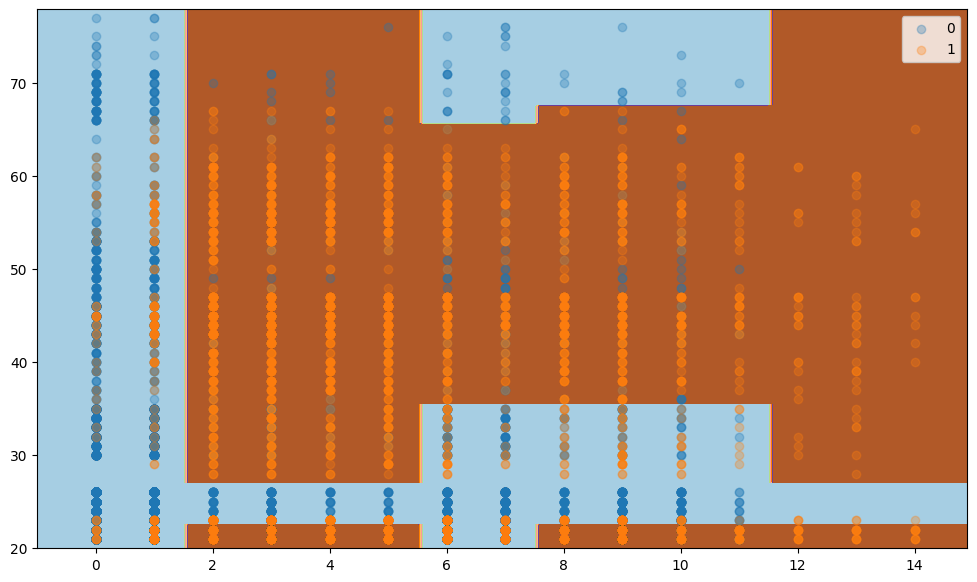

In [75]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# =========================
# 1. Model bazowy (weak learner)
# =========================
# AdaBoost buduje model na prostych drzewach decyzyjnych
# max_depth=1 oznacza tzw. "decision stump" (bardzo proste drzewo)
base_model = DecisionTreeClassifier(max_depth=1)

# =========================
# 2. Model AdaBoost
# =========================
# AdaBoost działa sekwencyjnie:
# - kolejne drzewa uczą się na błędach poprzednich
# - poprawiają trudne przypadki
model_adaboost = AdaBoostClassifier(
    estimator=base_model,  # model bazowy (wcześniej: base_estimator)
    n_estimators=50        # liczba iteracji / drzew w boosting
)

# =========================
# 3. Trenowanie modelu
# =========================
# model uczy się na danych treningowych
model_adaboost.fit(X_train, y_train)

# =========================
# 4. Wizualizacja granicy decyzyjnej
# =========================
# pokazuje jak model dzieli przestrzeń cech na klasy
# Uwaga: może być wolniejsze niż dla pojedynczego drzewa
plot_classification_surface(
    X_plot=np.array(X_train),  # dane do wizualizacji
    y_plot=y_train,            # etykiety klas
    trained_model=model_adaboost  # wytrenowany model
)

Najważniejsze rzeczy do zapamiętania
AdaBoost = model sekwencyjny (drzewa uczą się jedno po drugim)
DecisionTreeClassifier(max_depth=1) = bardzo słabe modele bazowe
n_estimators = ile takich “poprawek” model robi
estimator = nowa nazwa (zamiast base_estimator)

Model: AdaBoost
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      7000
           1       0.82      0.81      0.81      3500

    accuracy                           0.88     10500
   macro avg       0.86      0.86      0.86     10500
weighted avg       0.88      0.88      0.88     10500



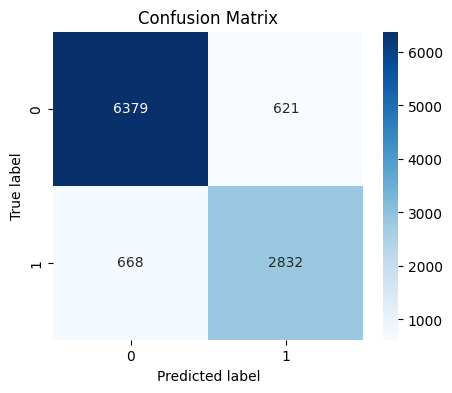

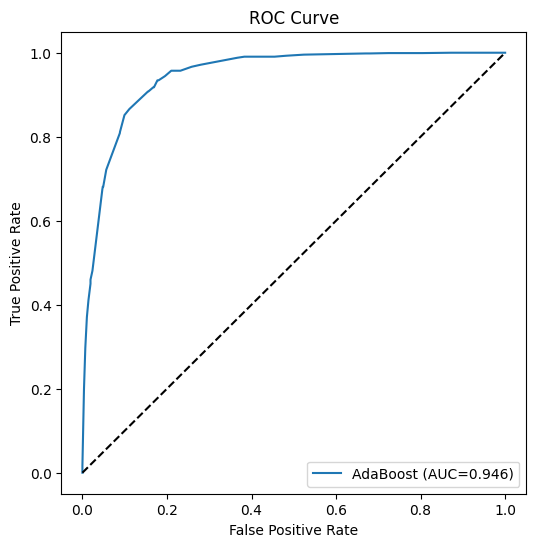

,Model,F1_score,AUC
0,model_svm,0.500000,0.500000
1,model_svm,0.786540,0.931629
2,AdaBoost,0.280737,0.635296
3,AdaBoost,0.814612,0.945675


In [77]:
calculate_metrics(model_adaboost, 'AdaBoost',X_train, y_train)

Nauczyliśmy najlepszy model do tej pory. Nie bez powodu ten model jest State of the Art w Data Science.

CWICZENIE

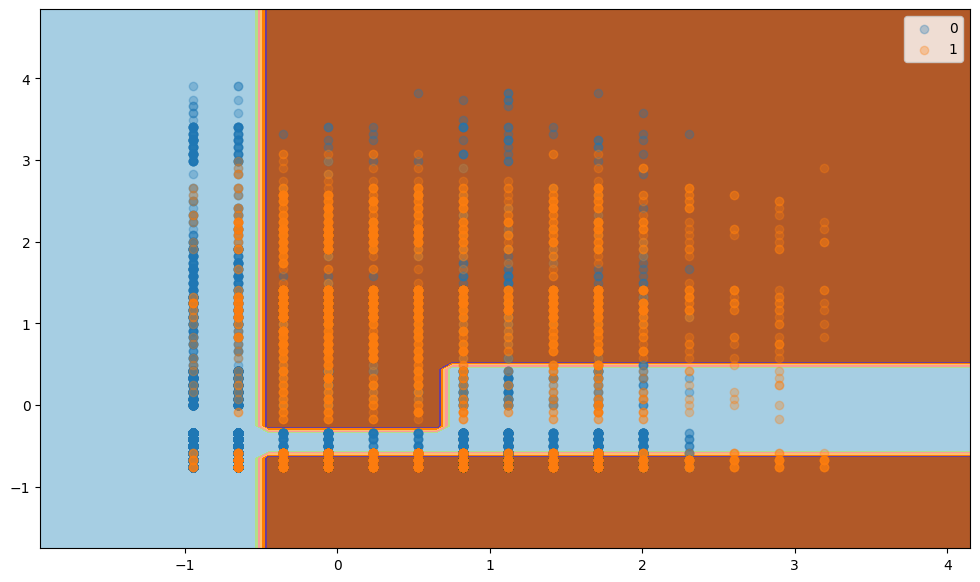

AdaBoost n_estimators = 10
F1 train: 0.7988
F1 test : 0.7934


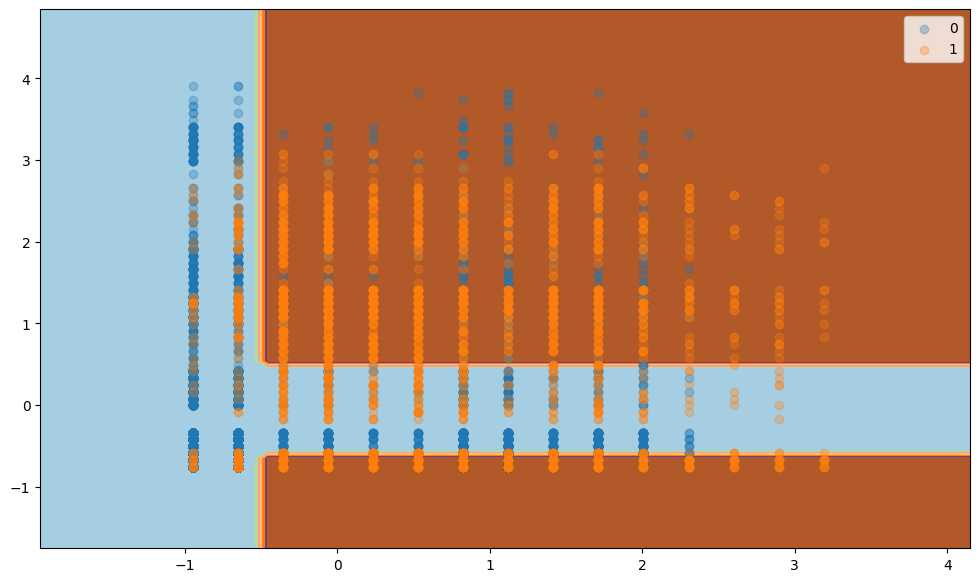

AdaBoost n_estimators = 30
F1 train: 0.7807
F1 test : 0.7753


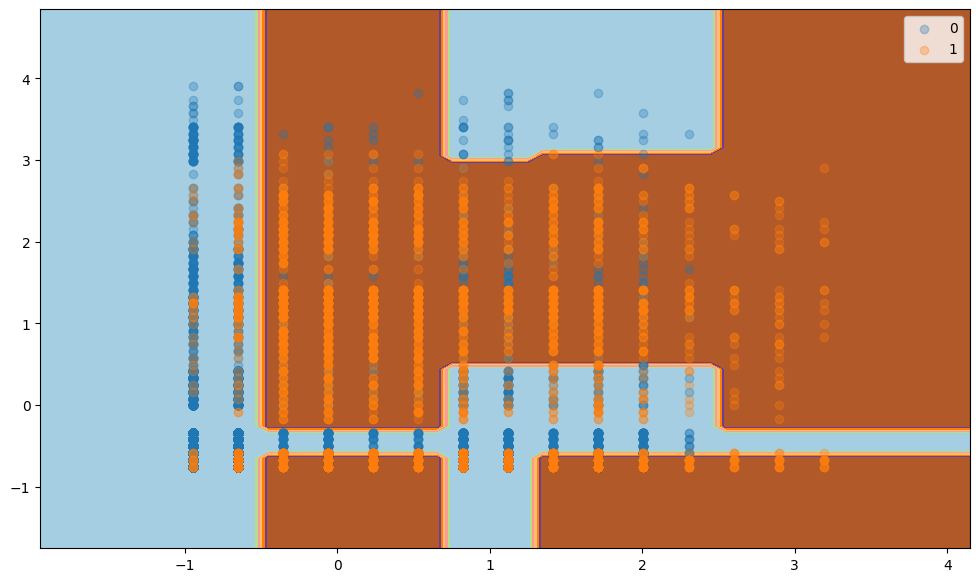

AdaBoost n_estimators = 50
F1 train: 0.8146
F1 test : 0.8093


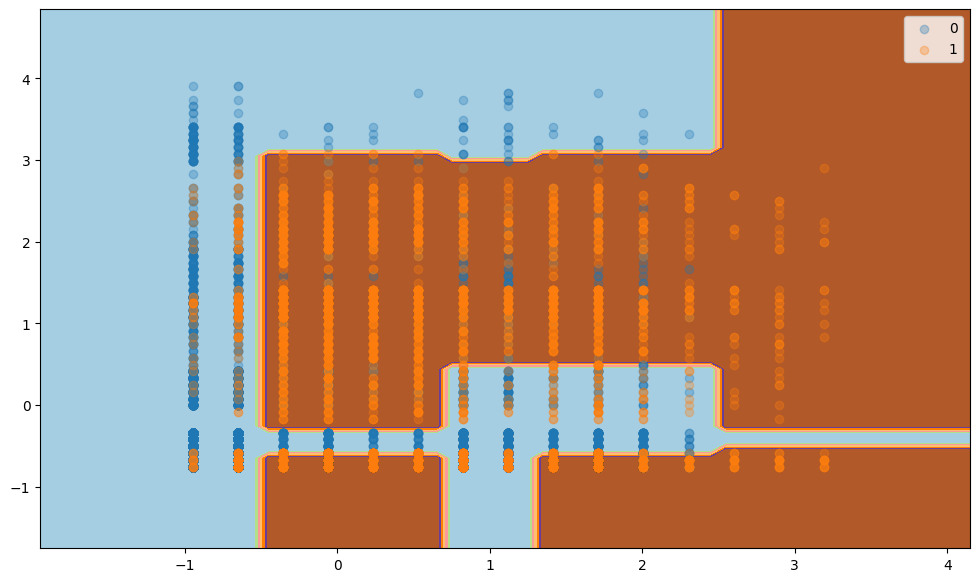

AdaBoost n_estimators = 100
F1 train: 0.8167
F1 test : 0.8130


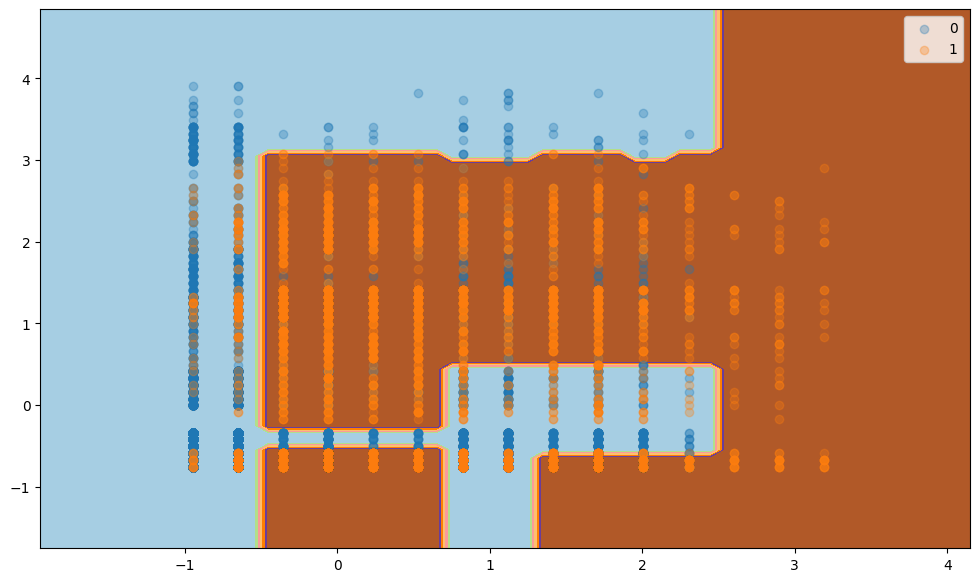

AdaBoost n_estimators = 200
F1 train: 0.8317
F1 test : 0.8269


In [79]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# różne liczby estymatorów do sprawdzenia
n_estimators_list = [10, 30, 50, 100, 200]

results = []

for n_estimators in n_estimators_list:

    # =========================
    # 1. Tworzenie modelu
    # =========================
    model_adaboost = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),  # słabe drzewka
        n_estimators=n_estimators,                      # liczba iteracji
        random_state=42
    )

    # =========================
    # 2. Trenowanie
    # =========================
    model_adaboost.fit(X_train_standardized, y_train)

    # =========================
    # 3. Wizualizacja
    # =========================
    plot_classification_surface(
        X_plot=X_train_standardized,
        y_plot=y_train,
        trained_model=model_adaboost
    )

    # =========================
    # 4. Predykcje
    # =========================
    y_pred_train = model_adaboost.predict(X_train_standardized)
    y_pred_test = model_adaboost.predict(X_test_standardized)

    # =========================
    # 5. F1-score
    # =========================
    f1_train = f1_score(y_train, y_pred_train)
    f1_test = f1_score(y_test, y_pred_test)

    print("=" * 50)
    print(f"AdaBoost n_estimators = {n_estimators}")
    print(f"F1 train: {f1_train:.4f}")
    print(f"F1 test : {f1_test:.4f}")

    # =========================
    # 6. zapis wyników
    # =========================
    results.append([n_estimators, f1_train, f1_test])